In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import os

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

curated_df = pd.read_csv("../data/xai_examples/curated_examples.csv")
images_dir = "../data/xai_examples"

print("Model loaded. Curated examples:", curated_df.shape)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Model loaded. Curated examples: (15, 5)


Check If BLIP Exposes Attention Weights

In [2]:
test_img_path = os.path.join(images_dir, curated_df['image'].iloc[0])
raw_image = Image.open(test_img_path).convert('RGB')
inputs = processor(raw_image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=20, output_attentions=True, return_dict_in_generate=True)

generated_caption = processor.decode(outputs.sequences[0], skip_special_tokens=True)
print("Generated caption:", generated_caption)
print("\nAttentions available:", outputs.attentions is not None)
if outputs.attentions is not None:
    print("Number of generation steps with attention:", len(outputs.attentions))

Generated caption: a dog running with a stick in its mouth

Attentions available: True
Number of generation steps with attention: 10


Function: Visualize Attention Alignment

In [3]:
def visualize_attention_alignment(image_path, max_words=5):
    raw_image = Image.open(image_path).convert('RGB')
    inputs = processor(raw_image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=20, output_attentions=True, return_dict_in_generate=True)

    generated_ids = outputs.sequences[0]
    generated_caption = processor.decode(generated_ids, skip_special_tokens=True)
    words = generated_caption.split()[:max_words]

    fig, axes = plt.subplots(1, len(words), figsize=(4*len(words), 4))
    if len(words) == 1:
        axes = [axes]

    for i, word in enumerate(words):
        try:
            cross_attn = outputs.attentions[i][-1][0].mean(dim=0)
            attn_map = cross_attn[0, 1:].detach().cpu().numpy()
            num_patches = int(np.sqrt(len(attn_map)))
            attn_map = attn_map[:num_patches**2].reshape(num_patches, num_patches)

            axes[i].imshow(raw_image)
            axes[i].imshow(attn_map, cmap='jet', alpha=0.5, extent=(0, raw_image.width, raw_image.height, 0))
            axes[i].set_title(f"'{word}'", fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            axes[i].set_title(f"'{word}' (unavailable)")
            axes[i].axis('off')

    plt.tight_layout()
    return fig, generated_caption

Test Attention Alignment On One Image

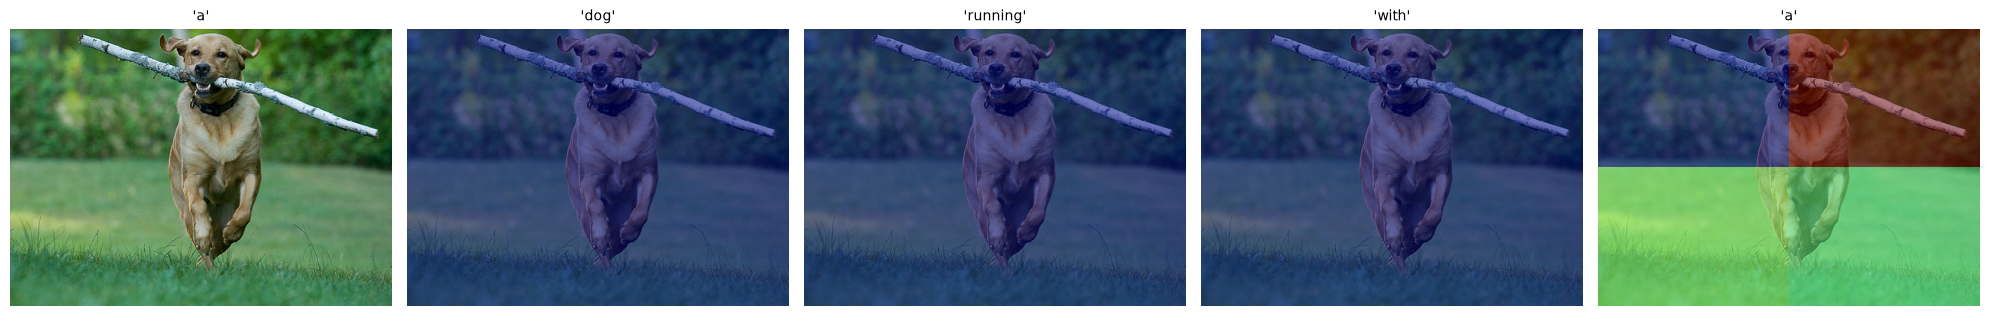

Caption: a dog running with a stick in its mouth


In [4]:
test_img_path = os.path.join(images_dir, curated_df['image'].iloc[0])
fig, caption = visualize_attention_alignment(test_img_path)
plt.show()
print("Caption:", caption)

SHAP/LIME On Text Generation

In [8]:
def occlusion_importance(image_path, patch_size=32):
    raw_image = Image.open(image_path).convert('RGB').resize((224, 224))
    img_array = np.array(raw_image)

    inputs = processor(raw_image, return_tensors="pt").to(device)
    with torch.no_grad():
        original_out = model.generate(**inputs, max_new_tokens=20)
    original_caption = processor.decode(original_out[0], skip_special_tokens=True)

    h, w, _ = img_array.shape
    importance_map = np.zeros((h // patch_size, w // patch_size))

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            occluded = img_array.copy()
            occluded[i:i+patch_size, j:j+patch_size] = 128  # gray patch

            occluded_pil = Image.fromarray(occluded)
            occ_inputs = processor(occluded_pil, return_tensors="pt").to(device)
            with torch.no_grad():
                occ_out = model.generate(**occ_inputs, max_new_tokens=20)
            occ_caption = processor.decode(occ_out[0], skip_special_tokens=True)

            # Importance = how different the caption becomes when this patch is hidden
            diff = len(set(original_caption.split()) - set(occ_caption.split()))
            importance_map[i//patch_size, j//patch_size] = diff

    return raw_image, importance_map, original_caption

Test Occlusion Importance On One Image

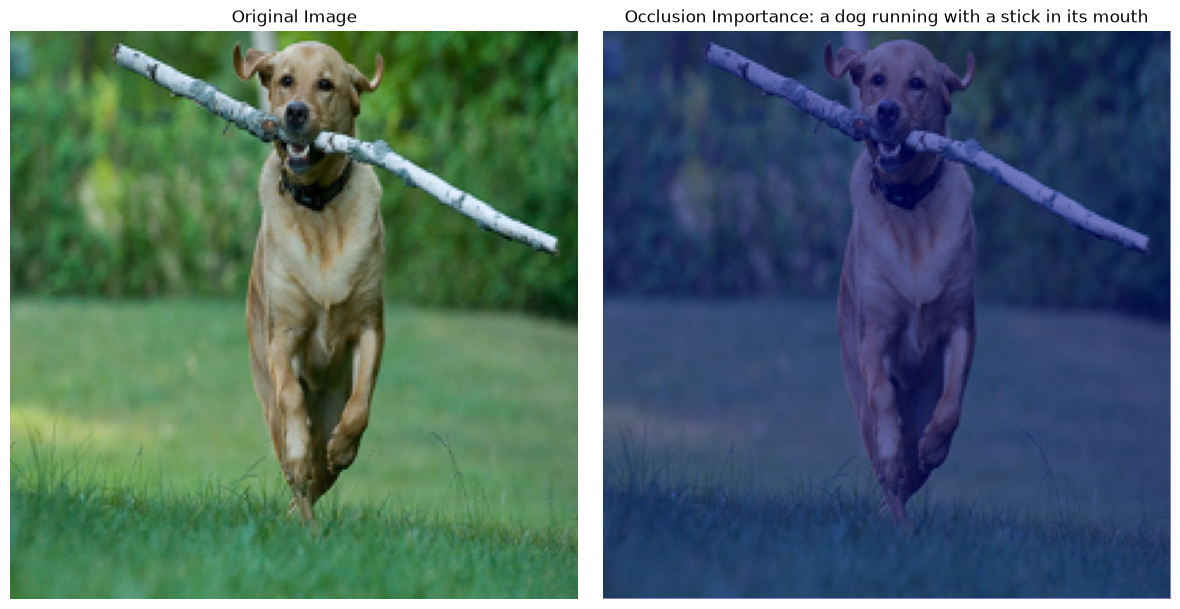

In [9]:
test_img_path = os.path.join(images_dir, curated_df['image'].iloc[0])
raw_image, importance_map, caption = occlusion_importance(test_img_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(raw_image)
axes[1].imshow(importance_map, cmap='jet', alpha=0.5, extent=(0, 224, 224, 0))
axes[1].set_title(f"Occlusion Importance: {caption}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Apply To All Curated Examples

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(24, 20))

for idx, row in curated_df.iterrows():
    img_path = os.path.join(images_dir, row['image'])
    raw_image, importance_map, caption = occlusion_importance(img_path, patch_size=56)

    ax1 = axes[idx, 0] if idx < 5 else None
    # Simplified: just show overlay for each example in sequence
    plt.subplot(5, 3, idx+1)
    plt.imshow(raw_image)
    plt.imshow(importance_map, cmap='jet', alpha=0.5, extent=(0, 224, 224, 0))
    plt.title(f"[{row['category']}] {caption[:30]}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig("occlusion_importance_all_examples.png")
plt.show()